# Adaptive Linguistic Sanitization & Anonymization (ALSA) — Google Colab Edition

This notebook is a **Google Colab port** of the original `transformer.py` privacy pipeline.
Every computational step, formula, and threshold from the local implementation is preserved
identically. The only material change is the **Llama-3 backbone**: the original used Apple's
MLX framework (Metal / Apple Silicon only). In Colab we use Hugging Face `transformers` +
`bitsandbytes` for 4-bit quantised inference on CUDA.

## What the pipeline does

Given a natural-language prompt, it assigns one of four actions to every word — **Retain,
Delete, Replace, Encrypt** — based on three orthogonal per-word scores:

| Score | Intuition | Components |
|---|---|---|
| **PLRS** — Privacy Leakage Risk | How identifying is this word? | Isolation Forest on BERT + GPT-2 NLL exposure + PII regex + spaCy NER |
| **CIIS** — Contextual Information Importance | How structurally important is it to the sentence? | Mahalanobis distance from POS-weighted centroid + MMD over WordNet mutants |
| **TRS** — Task Relevance | How relevant is it to the task the prompt describes? | k-shot Llama-3 self-score |

Actions are decided by the ALSA Table-1 rule (`(P,C,T) → Action`) with a hard PII override.
`Encrypt` further runs an LLM self-recommendation over m candidate fill-ins.

## Libraries & Models

- **BERT** (`bert-base-uncased`) — contextual & isolated word embeddings (768-d)
- **GPT-2** (`gpt2`) — per-token Negative Log-Likelihood for Exposure Risk
- **spaCy** (`en_core_web_sm`) — NER + POS tagging + dependency parsing
- **WordNet** (via NLTK) — POS-safe synonym pool
- **Isolation Forest** (scikit-learn) — anomaly detection against 10 000 common Brown-corpus words
- **Llama-3-8B-Instruct (4-bit, bitsandbytes)** — TRS scoring + Encrypt self-recommendation

## Colab runtime

Set **Runtime → Change runtime type → GPU** (T4 / V100 / L4 / A100 all work; the 4-bit
Llama-3 checkpoint fits in ~6 GB of VRAM). Colab Pro's higher-RAM T4 or any V100/A100 is
recommended for comfortable throughput.


## 1. Runtime check

Verify that a CUDA GPU is attached before installing heavy dependencies.


In [1]:
import subprocess
try:
    print(subprocess.check_output(['nvidia-smi'], text=True))
except Exception as exc:
    print('nvidia-smi not available:', exc)
    print('WARNING: switch runtime to GPU (Runtime → Change runtime type → GPU).')


Wed Apr 22 10:02:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   63C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Install dependencies

Colab already ships `torch`, `numpy`, `scikit-learn`, `scipy`, `matplotlib`. We install the
remaining packages with pinned versions known to be mutually compatible as of early 2026.

- `transformers` — BERT / GPT-2 / Llama-3 loading
- `accelerate` — device placement for quantised models
- `bitsandbytes` — 4-bit quantisation kernels (CUDA)
- `sentencepiece`, `protobuf` — tokenizer dependencies for Llama-3
- `spacy`, `nltk` — linguistic utilities
- `fastapi`, `pydantic` — kept so the original REST wrapper still works verbatim


In [2]:
!pip install -q \
    'transformers>=4.44,<4.47' \
    'accelerate>=0.33' \
    'bitsandbytes>=0.45' \
    'sentencepiece>=0.2' \
    'spacy>=3.8.2,<3.9' \
    'nltk>=3.9,<3.10' \
    'scikit-learn>=1.3' \
    'scipy>=1.11' \
    'fastapi' \
    'pydantic'


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 61.3 MB/s eta 0:00:00


In [3]:
# spaCy English model (small) — ~12 MB
!python -m spacy download en_core_web_sm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 59.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [4]:
# NLTK corpora: WordNet (synonyms), OMW (multilingual WordNet links), Brown (freq)
import nltk
for pkg in ('wordnet', 'omw-1.4', 'brown'):
    nltk.download(pkg, quiet=True)
print('NLTK corpora ready.')


NLTK corpora ready.


## 3. Imports

Exactly the same stack as the original `transformer.py`, with MLX-specific imports removed
and replaced by `BitsAndBytesConfig` from `transformers`.


In [5]:
# ── Standard Library ─────────────────────────────────────────────────────────
import asyncio
import json
import logging
import os
import re
import time
from contextlib import asynccontextmanager
from pathlib import Path
from typing import Dict, List, Optional, Tuple

# ── Third-Party ───────────────────────────────────────────────────────────────
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from transformers import (
    AutoModel,
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
)

import spacy
import nltk
from nltk.corpus import wordnet as wn

from sklearn.ensemble import IsolationForest
from sklearn.metrics.pairwise import rbf_kernel

from scipy.spatial.distance import mahalanobis

from fastapi import FastAPI, HTTPException
from pydantic import BaseModel

# ── Logging ───────────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s  [%(levelname)s]  %(name)s — %(message)s',
    datefmt='%H:%M:%S',
)
log = logging.getLogger('privacy_pipeline')


## 4. Constants

Same thresholds and weights as the paper / original script. The only Llama-3 constant that
changed is `LLAMA_MODEL_NAME`: Colab cannot use the `mlx-community/*` checkpoint because it
ships in MLX's safetensors layout for Metal. We use `unsloth/llama-3-8b-Instruct-bnb-4bit`
— a bitsandbytes-native 4-bit quantisation of the same base weights (`meta-llama/Meta-Llama-
3-8B-Instruct`), re-hosted without the gate so no HF token is required.


In [6]:
# ── Constants ─────────────────────────────────────────────────────────────────
BERT_MODEL_NAME   = 'bert-base-uncased'
GPT2_MODEL_NAME   = 'gpt2'
SPACY_MODEL_NAME  = 'en_core_web_sm'
CACHE_DIR         = Path('./model_cache')
BERT_CACHE_FILE   = CACHE_DIR / 'bert_common_word_vectors.pt'
N_COMMON_WORDS    = 10_000
MAX_BERT_TOKENS   = 512
MASK_TOKEN        = '[MASK]'

# Absolute high/low thresholds used by ALSA Table-1 action rules.
PLRS_HIGH_THRESHOLD = 0.55
CIIS_HIGH_THRESHOLD = 0.55
TRS_HIGH_THRESHOLD  = 0.55

# Exposure risk is calibrated against fixed NLL bounds (absolute scale),
# not re-normalised within each prompt.
EXPOSURE_RISK_MIN_NLL = 2.0
EXPOSURE_RISK_MAX_NLL = 12.0

# NER contributions are intentionally soft so they cannot dominate PLRS.
NER_ENTITY_BOOST  = 0.25
NER_PROPN_BOOST   = 0.15
NER_FUSION_WEIGHT = 0.20

# Replace-action quality controls.
REPLACE_MIN_FREQUENCY    = 2
REPLACE_MIN_SEMANTIC_SIM = 0.90
REPLACE_MAX_CANDIDATES   = 10

# ── Llama-3 Backbone (TRS + Encrypt Self-Recommendation) ─────────────
# CHANGED FROM ORIGINAL: uses HF-compatible 4-bit checkpoint instead of mlx-community.
# This is a re-quantisation of meta-llama/Meta-Llama-3-8B-Instruct with identical weights
# before quantisation; behaviour is functionally equivalent to the MLX 4-bit build.
LLAMA_MODEL_NAME          = 'unsloth/llama-3-8b-Instruct-bnb-4bit'
TRS_NUM_ITERS             = 5           # k in TRS(w_i) = (1/k) Σ LLM_j(w_i|P)
TRS_FALLBACK_SCORE        = 0.5         # graceful fallback if LLM fails
TRS_MAX_TOKENS            = 16          # response is a single float

# Encrypt self-recommendation weights:
#   Score(P'_i) = α·Fluency + β·Coherence + γ·TaskConsistency
ENCRYPT_NUM_CANDIDATES    = 3           # m candidate completions
ENCRYPT_CANDIDATE_TOKENS  = 256         # max tokens for candidate generation
ENCRYPT_ALPHA             = 0.33        # fluency weight
ENCRYPT_BETA              = 0.33        # coherence weight
ENCRYPT_GAMMA             = 0.34        # task-consistency weight

# POS → coherence weight
POS_WEIGHT: Dict[str, float] = {
    'NOUN': 1.0, 'PROPN': 1.0, 'ADJ': 1.0, 'ADV': 0.8, 'VERB': 0.9,
    'ADP':  0.3, 'DET':  0.3, 'CONJ': 0.3, 'CCONJ': 0.3,
    'SCONJ':0.3, 'PART': 0.3, 'PRON': 0.5, 'NUM':   0.7,
    'PUNCT':0.1, 'SYM':  0.2, 'X':    0.5, 'INTJ':  0.6,
}

# ── PII Regex Patterns ────────────────────────────────────────────────────────
# Each entry: (compiled_pattern, override_plrs_score)
# A score of 1.0 means 'always Encrypt regardless of anything else'
PII_PATTERNS: List[Tuple[re.Pattern, float]] = [
    (re.compile(r'\b\d{3}[-\s]\d{2}[-\s]\d{4}\b'),             1.0),   # SSN
    (re.compile(r'\b\d{3}[-.\s]?\d{3}[-.\s]?\d{4}\b'),          0.95),  # Phone
    (re.compile(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b'), 0.95),  # Email
    (re.compile(r'\b\d{4}[- ]?\d{4}[- ]?\d{4}[- ]?\d{4}\b'),   0.95),  # Credit card
    (re.compile(r'\b\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}\b'),    0.90),  # IP address
    (re.compile(r'\b(?:19|20)\d{2}[-/]\d{2}[-/]\d{2}\b'),       0.80),  # ISO date
    (re.compile(r'\$\s*\d[\d,]*(?:\.\d{2})?\b'),                0.75),  # Dollar amounts
    (re.compile(r'\b\d+\s*(?:million|billion|thousand)\b', re.I), 0.70),  # Large sums
]

# SpaCy NER labels that indicate high-sensitivity named entities.
SENSITIVE_NER_LABELS = {'PERSON', 'ORG', 'GPE', 'LOC', 'MONEY'}

# spaCy POS to WordNet POS mapping for POS-safe synonym retrieval.
_SPACY_TO_WN_POS: Dict[str, str] = {
    'NOUN': wn.NOUN, 'VERB': wn.VERB, 'ADJ': wn.ADJ, 'ADV': wn.ADV,
}

# Lazy Brown-corpus frequency cache used to avoid obscure replacements.
_BROWN_FREQ_CACHE: Optional[Dict[str, int]] = None


## 5. Model registry

A single global object holds every loaded model. The original used it to share state between
FastAPI request handlers; we keep the same structure so all downstream functions remain
unchanged. The only change is that `llama_model` / `llama_tokenizer` are now HF objects
instead of `mlx_lm` handles.


In [7]:
class ModelRegistry:
    device: torch.device
    bert_tokenizer: AutoTokenizer
    bert_model: AutoModel
    gpt2_tokenizer: AutoTokenizer
    gpt2_model: AutoModelForCausalLM
    spacy_nlp: spacy.Language
    bert_common_vectors: torch.Tensor  # (N_COMMON_WORDS, 768)
    llama_model: AutoModelForCausalLM  # HF-quantised Llama-3
    llama_tokenizer: AutoTokenizer     # HF tokenizer

registry = ModelRegistry()


## 6. Phase 1 — environment & model loading

`detect_device()` picks CUDA if available (Colab), falling back to MPS (local Apple Silicon)
or CPU. `load_bert()` / `load_gpt2()` are unchanged. `load_llama()` is rewritten to use HF
`transformers` + `bitsandbytes` 4-bit quantisation.


In [8]:
def detect_device() -> torch.device:
    """CUDA → MPS → CPU."""
    if torch.cuda.is_available():
        log.info('Device: CUDA — %s', torch.cuda.get_device_name(0))
        return torch.device('cuda')
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        log.info('Device: Apple MPS'); return torch.device('mps')
    log.info('Device: CPU'); return torch.device('cpu')


def load_bert(device: torch.device):
    log.info('Loading BERT …')
    tok = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)
    mdl = AutoModel.from_pretrained(BERT_MODEL_NAME).to(device).eval()
    return tok, mdl


def load_gpt2(device: torch.device):
    log.info('Loading GPT-2 …')
    tok = AutoTokenizer.from_pretrained(GPT2_MODEL_NAME)
    mdl = AutoModelForCausalLM.from_pretrained(GPT2_MODEL_NAME).to(device).eval()
    return tok, mdl


### 6.1 Llama-3 loader (HF + bitsandbytes, replaces MLX)

The original used `mlx_lm.load(...)` which only runs on Apple's Metal backend. In Colab we:

1. Build a `BitsAndBytesConfig` that specifies **NF4 4-bit quantisation** with a float16
   compute dtype and double quantisation — the standard bnb recipe that matches what MLX
   produced on the other side.
2. Load `unsloth/llama-3-8b-Instruct-bnb-4bit` with `device_map='auto'` so the model shards
   straight onto the GPU. The Unsloth checkpoint is *already* 4-bit on disk, so the download
   is ~5 GB (not 16 GB) and loading takes <30 s on a T4.
3. Keep `apply_chat_template(...)` identical — the Llama-3 chat format is model-defined, not
   framework-defined, so the same template works here.


In [9]:
def load_llama():
    """
    Load Llama-3-8B-Instruct quantised to 4-bit via bitsandbytes.

    Colab port of the original Apple-MLX loader. Uses a pre-quantised checkpoint
    (unsloth/llama-3-8b-Instruct-bnb-4bit) so no on-the-fly quantisation pass is
    needed and there is no HF-hub gate. Requires ~5–6 GB of GPU memory.
    """
    log.info('Loading Llama-3 backbone (%s) …', LLAMA_MODEL_NAME)

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )

    tokenizer = AutoTokenizer.from_pretrained(LLAMA_MODEL_NAME)
    model = AutoModelForCausalLM.from_pretrained(
        LLAMA_MODEL_NAME,
        quantization_config=bnb_config,
        device_map='auto',
        torch_dtype=torch.float16,
    )
    model.eval()

    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    log.info('Llama-3 loaded on %s (bitsandbytes 4-bit NF4)', next(model.parameters()).device)
    return model, tokenizer


@torch.no_grad()
def _llama_generate(prompt_text: str, max_tokens: int = 16) -> str:
    """
    Synchronous single-call Llama-3 generation via HF `generate`.

    Applies the Llama-3 Instruct chat template exactly as the MLX version did,
    then greedy-decodes up to *max_tokens* tokens. Returns ONLY the assistant's
    response text (the input prompt is stripped from the output ids).

    Called from async code via ``loop.run_in_executor`` so the GIL releases
    during the CUDA forward pass.
    """
    messages = [{'role': 'user', 'content': prompt_text}]
    formatted = registry.llama_tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True,
    )
    inputs = registry.llama_tokenizer(formatted, return_tensors='pt').to(
        registry.llama_model.device
    )
    output_ids = registry.llama_model.generate(
        **inputs,
        max_new_tokens=max_tokens,
        do_sample=False,
        pad_token_id=registry.llama_tokenizer.eos_token_id,
    )
    # Strip the prompt tokens; return just the completion.
    response_ids = output_ids[0, inputs['input_ids'].shape[1]:]
    return registry.llama_tokenizer.decode(response_ids, skip_special_tokens=True)


### 6.2 BERT reference vectors (Isolation Forest corpus)

The Isolation Forest needs a "normal" distribution to fit against. We use the 10 000 most
frequent words in the Brown corpus, each embedded **in isolation** (single word → `[CLS]`).
This is critical: prompt words in the PLRS step are also embedded in isolation, so the
forest sees comparable vectors on both sides. Mixing contextual and non-contextual
embeddings produces garbage anomaly scores.

The embedded tensor is cached to `./model_cache/bert_common_word_vectors.pt` so subsequent
runs skip the ~60 s embedding pass.


In [10]:
def _build_bert_common_vectors(tokenizer, model, device) -> torch.Tensor:
    """
    Offline: embed N_COMMON_WORDS from the Brown corpus in ISOLATION
    (single word → [CLS] vector). This is the 'normal' reference
    distribution for the Isolation Forest.

    CRITICAL: words are embedded one-at-a-time (no context), so the
    Isolation Forest sees the same kind of vector as prompt words will
    be scored with (isolated embeddings, not contextual).
    """
    from nltk.corpus import brown
    nltk.download('brown', quiet=True)
    CACHE_DIR.mkdir(parents=True, exist_ok=True)

    freq: Dict[str, int] = {}
    for w in brown.words():
        lw = w.lower()
        if lw.isalpha():
            freq[lw] = freq.get(lw, 0) + 1

    common_words = sorted(freq, key=freq.get, reverse=True)[:N_COMMON_WORDS]  # type: ignore
    log.info('  Embedding %d common words …', len(common_words))

    vectors: List[torch.Tensor] = []
    bs = 64
    for i in range(0, len(common_words), bs):
        batch = common_words[i : i + bs]
        enc = tokenizer(batch, return_tensors='pt', padding=True,
                        truncation=True, max_length=16).to(device)
        with torch.no_grad():
            out = model(**enc)
        vectors.append(out.last_hidden_state[:, 0, :].cpu())

    all_vecs = torch.cat(vectors, dim=0)
    torch.save(all_vecs, BERT_CACHE_FILE)
    log.info('  Cached → %s  shape=%s', BERT_CACHE_FILE, all_vecs.shape)
    return all_vecs


def load_bert_common_vectors(tokenizer, model, device) -> torch.Tensor:
    if BERT_CACHE_FILE.exists():
        log.info('Loading cached BERT reference vectors …')
        vecs = torch.load(BERT_CACHE_FILE, map_location='cpu')
        log.info('  shape: %s', vecs.shape)
        return vecs
    return _build_bert_common_vectors(tokenizer, model, device)


### 6.3 Initialise every model (one-time setup)

Run this cell once per Colab session. First run downloads the BERT / GPT-2 / Llama-3
weights from Hugging Face (~10 GB total across all three) and builds the Brown corpus
reference cache. Subsequent runs within the same runtime are essentially instant because
everything is cached on disk or already in memory.


In [11]:
registry.device = detect_device()
registry.bert_tokenizer, registry.bert_model = load_bert(registry.device)
registry.gpt2_tokenizer, registry.gpt2_model = load_gpt2(registry.device)
log.info('Loading SpaCy …')
registry.spacy_nlp = spacy.load(SPACY_MODEL_NAME)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
registry.bert_common_vectors = load_bert_common_vectors(
    registry.bert_tokenizer, registry.bert_model, registry.device
)
registry.llama_model, registry.llama_tokenizer = load_llama()
log.info('=== All models loaded. Pipeline ready. ===')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/345 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Unused kwargs: ['_load_in_4bit', '_load_in_8bit', 'quant_method']. These kwargs are not used in <class 'transformers.utils.quantization_config.BitsAndBytesConfig'>.
/usr/local/lib/python3.12/dist-packages/transformers/quantizers/auto.py:186: UserWarning: You passed `quantization_config` or equivalent parameters to `from_pretrained` but the model you're loading already has a `quantization_config` attribute. The `quantization_config` from the model will be used.
  warnings.warn(warning_msg)


model.safetensors:   0%|          | 0.00/5.70G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/220 [00:00<?, ?B/s]

## 7. Utility helpers

Small, pure-Python helpers used across every phase: punctuation stripping, character-level
word-span resolution, Brown-corpus frequency lookup, surface-form casing, POS mapping, and
two one-dimensional normalisation routines (`_robust_scale_1d` for context-relative and
`_fixed_range_scale_1d` for absolute-range calibration).


In [12]:
def strip_punctuation(word: str) -> str:
    """
    Remove leading/trailing punctuation from a surface token so BERT and
    GPT-2 receive clean lexical forms.
    """
    return re.sub(r"^[^\w]+|[^\w]+$", '', word) or word


def get_word_char_spans(words: List[str], text: str) -> List[Tuple[int, int]]:
    """Return (start, end) character indices for each surface word within `text`."""
    spans: List[Tuple[int, int]] = []
    cursor = 0
    for w in words:
        idx = text.find(w, cursor)
        if idx == -1:
            idx = cursor
        spans.append((idx, idx + len(w)))
        cursor = idx + len(w)
    return spans


def _get_brown_frequency_map() -> Dict[str, int]:
    """Load Brown word frequencies once for replacement naturalness scoring."""
    global _BROWN_FREQ_CACHE
    if _BROWN_FREQ_CACHE is None:
        from nltk.corpus import brown
        nltk.download('brown', quiet=True)
        freq: Dict[str, int] = {}
        for w in brown.words():
            lw = w.lower()
            if lw.isalpha():
                freq[lw] = freq.get(lw, 0) + 1
        _BROWN_FREQ_CACHE = freq
    return _BROWN_FREQ_CACHE


def _word_frequency(word: str) -> int:
    return int(_get_brown_frequency_map().get(word.lower(), 0))


def _frequency_score(word: str) -> float:
    """Frequency proxy in [0, 1] for lexical naturalness."""
    freq = _word_frequency(strip_punctuation(word))
    return float(np.clip(np.log1p(freq) / np.log1p(5000.0), 0.0, 1.0))


def _apply_surface_form(source_word: str, replacement: str) -> str:
    """Preserve source casing and edge punctuation for a replacement token."""
    m = re.match(r"^([^\w]*)([\w'-]+)([^\w]*)$", source_word)
    if not m:
        return replacement

    prefix, core, suffix = m.groups()
    rep = replacement
    if core.isupper():
        rep = rep.upper()
    elif core.istitle():
        rep = rep.title()
    return f'{prefix}{rep}{suffix}'


def _get_word_pos_tags(words: List[str], prompt: str, spacy_nlp: spacy.Language) -> List[str]:
    """Map each split-word to the best-overlap spaCy POS tag."""
    doc = spacy_nlp(prompt)
    spans = get_word_char_spans(words, prompt)
    tags: List[str] = []

    for ws, we in spans:
        best_overlap = 0
        best_pos = 'X'
        for tok in doc:
            if tok.is_space:
                continue
            ts, te = tok.idx, tok.idx + len(tok.text)
            overlap = max(0, min(we, te) - max(ws, ts))
            if overlap > best_overlap:
                best_overlap = overlap
                best_pos = tok.pos_
        tags.append(best_pos)

    return tags


def _robust_scale_1d(arr: np.ndarray) -> np.ndarray:
    """
    Percentile-clipped Min-Max normalisation.
    Clip to [p5, p95] first to remove extreme outliers, then scale to [0, 1].
    For small arrays (< 10 elements) percentile clipping is skipped.
    """
    if len(arr) >= 10:
        lo = float(np.percentile(arr, 5))
        hi = float(np.percentile(arr, 95))
        arr = np.clip(arr, lo, hi)
    lo, hi = arr.min(), arr.max()
    return ((arr - lo) / (hi - lo + 1e-9)).astype(np.float32)


def _fixed_range_scale_1d(arr: np.ndarray, lo: float, hi: float) -> np.ndarray:
    """Absolute scaling to [0, 1] using a fixed numeric range."""
    if hi <= lo:
        raise ValueError('Invalid fixed scaling range: hi must be > lo')
    scaled = (arr - lo) / (hi - lo)
    return np.clip(scaled, 0.0, 1.0).astype(np.float32)


### 7.1 BERT embedding helpers

Three variants of BERT embedding are used:

- `embed_sentences_bert` — `[CLS]` vector of whole sentences (for fluency, MMD, similarity).
- `embed_words_isolated_bert` — each word alone → `[CLS]`. Matches the reference corpus;
  feeds the Isolation Forest.
- `embed_words_in_context_bert` — contextual word vectors via **character-overlap offset
  mapping**, averaging every sub-token that falls inside a surface word's character span.
  Feeds CIIS contextual coherence.


In [13]:
@torch.no_grad()
def embed_sentences_bert(
    sentences: List[str],
    tokenizer: AutoTokenizer,
    model: AutoModel,
    device: torch.device,
    batch_size: int = 16,
) -> torch.Tensor:
    """Return [CLS] embedding for each sentence. Shape: (N, 768)."""
    all_cls: List[torch.Tensor] = []
    for i in range(0, len(sentences), batch_size):
        batch = sentences[i : i + batch_size]
        enc = tokenizer(batch, return_tensors='pt', padding=True,
                        truncation=True, max_length=MAX_BERT_TOKENS).to(device)
        out = model(**enc)
        all_cls.append(out.last_hidden_state[:, 0, :].cpu())
    return torch.cat(all_cls, dim=0)


@torch.no_grad()
def embed_words_isolated_bert(
    words: List[str],
    tokenizer: AutoTokenizer,
    model: AutoModel,
    device: torch.device,
) -> torch.Tensor:
    """
    Embed each word IN ISOLATION (no surrounding context) using [CLS].
    Matches the construction of the reference cache so the Isolation Forest
    compares like with like.
    """
    clean_words = [strip_punctuation(w) for w in words]
    return embed_sentences_bert(clean_words, tokenizer, model, device)


@torch.no_grad()
def embed_words_in_context_bert(
    words: List[str],
    prompt: str,
    tokenizer: AutoTokenizer,
    model: AutoModel,
    device: torch.device,
) -> torch.Tensor:
    """
    Embed words using their CONTEXTUAL BERT representation.

    Uses offset_mapping to find which sub-tokens correspond to which
    surface word by CHARACTER OVERLAP. Averages ALL sub-tokens that
    belong to the word; falls back to [CLS] only when no sub-token
    overlaps (very rare).
    """
    enc_raw = tokenizer(
        prompt, return_tensors='pt',
        truncation=True, max_length=MAX_BERT_TOKENS,
        return_offsets_mapping=True,
    )
    offsets: List[Tuple[int, int]] = enc_raw.pop('offset_mapping')[0].tolist()
    enc = {k: v.to(device) for k, v in enc_raw.items()}

    out = model(**enc)
    hidden = out.last_hidden_state[0].cpu()  # (seq_len, 768)

    word_spans = get_word_char_spans(words, prompt)

    word_vecs: List[torch.Tensor] = []
    for (ws, we) in word_spans:
        sub_vecs: List[torch.Tensor] = []
        for t_idx, (ts, te) in enumerate(offsets):
            if ts == 0 and te == 0:
                continue
            if ts < we and te > ws:
                sub_vecs.append(hidden[t_idx])
        if sub_vecs:
            word_vecs.append(torch.stack(sub_vecs).mean(0))
        else:
            word_vecs.append(hidden[0])

    return torch.stack(word_vecs, dim=0)


## 8. Phase 2 — Privacy Leakage Risk Score (PLRS)

PLRS quantifies *how identifying* each word is. It fuses four signals:

1. **PII regex override** — hard, score-based: SSN = 1.0, phone/email/credit-card = 0.95, etc.
2. **SpaCy NER boost** — soft additive bump of +0.25 for `PERSON/ORG/GPE/LOC/MONEY` spans
   and +0.15 for bare proper nouns.
3. **Intrinsic sensitivity** (Isolation Forest) — percentile-rank anomaly of the word's
   isolated BERT embedding against 10 000 common-word references.
4. **Exposure risk** (GPT-2 NLL) — how surprising the word is to a general LM, mapped through
   a **fixed** NLL range [2.0, 12.0] (absolute, not per-prompt).

Final fusion:

$$
\text{PLRS}_i = \max\!\Big( \operatorname{clip}\big(0.5\,\text{Intrinsic}_i + 0.5\,\text{Exposure}_i + \lambda\,\text{NER}_i,\; 0, 1\big),\; \text{PII}_i \Big)
$$


In [14]:
# ── Regex-based PII ──────────────────────────────────────────────────────────
def compute_pii_override_scores(words: List[str], prompt: str) -> np.ndarray:
    """
    Hard PII detection layer using regex.

    Runs BEFORE the statistical pipeline and produces a per-word
    override score. Words matched by PII patterns receive a score >= 0.7;
    unmatched words receive 0.0.
    """
    override = np.zeros(len(words), dtype=np.float32)
    word_spans = get_word_char_spans(words, prompt)

    for pattern, score in PII_PATTERNS:
        for m in pattern.finditer(prompt):
            ms, me = m.start(), m.end()
            for i, (ws, we) in enumerate(word_spans):
                if ws < me and we > ms:
                    override[i] = max(override[i], score)

    return override


# ── NER-based PII (ALSA v2.1 extension) ──────────────────────────────────────
# Labels that are *always* encrypted, identical tier to regex PII.
# PERSON is the core case (common given names like 'John' have low statistical
# PLRS but must still be anonymised). Expand set if ORG/GPE should also be
# force-encrypted in your domain.
NER_PII_OVERRIDE_LABELS = {"PERSON"}
NER_PII_OVERRIDE_SCORE  = 0.95


def compute_ner_pii_override(
    words: List[str],
    prompt: str,
    spacy_nlp: spacy.Language,
) -> np.ndarray:
    """
    Hard PII override for high-confidence named entities.

    In the original design PERSON got only a soft +0.25 boost, which is
    insufficient when the base PLRS (Isolation Forest + Exposure) is low —
    common given names like 'John' then escape encryption. This function
    adds an explicit hard override so any spaCy-confirmed PERSON entity
    is treated identically to a regex-confirmed SSN / phone / email.
    """
    doc = spacy_nlp(prompt)
    word_spans = get_word_char_spans(words, prompt)
    override = np.zeros(len(words), dtype=np.float32)

    for ent in doc.ents:
        if ent.label_ in NER_PII_OVERRIDE_LABELS:
            for i, (ws, we) in enumerate(word_spans):
                if ws < ent.end_char and we > ent.start_char:
                    override[i] = max(override[i], NER_PII_OVERRIDE_SCORE)

    return override


def compute_ner_sensitivity_boost(
    words: List[str],
    prompt: str,
    spacy_nlp: spacy.Language,
) -> np.ndarray:
    """
    SpaCy NER soft boost (unchanged from v2).

    SENSITIVE_NER_LABELS spans → NER_ENTITY_BOOST (0.25)
    PROPN (proper noun)         → NER_PROPN_BOOST  (0.15)

    For PERSON specifically, the boost is redundant because the new
    compute_ner_pii_override already forces encryption — but keeping it
    here is harmless (max() fuses to the higher signal).
    """
    doc = spacy_nlp(prompt)
    word_spans = get_word_char_spans(words, prompt)
    boost = np.zeros(len(words), dtype=np.float32)

    for ent in doc.ents:
        if ent.label_ in SENSITIVE_NER_LABELS:
            for i, (ws, we) in enumerate(word_spans):
                if ws < ent.end_char and we > ent.start_char:
                    boost[i] = max(boost[i], NER_ENTITY_BOOST)

    for tok in doc:
        if tok.pos_ == 'PROPN' and not tok.is_space:
            for i, w in enumerate(words):
                if tok.text.lower() == strip_punctuation(w).lower():
                    boost[i] = max(boost[i], NER_PROPN_BOOST)

    return boost


### 8.1 Intrinsic sensitivity (Isolation Forest, percentile-rank calibrated)

The original paper's formulation normalised anomaly scores **within the prompt**, which
inflates even the most common word to score 1.0 if every word in the prompt happens to be
common. The fix: fit the forest on the 10 000-word reference, then assign each prompt word
its **percentile rank** among reference anomaly scores. This yields an absolute, comparable
score across prompts — common words sit near 0.1–0.2, rare technical words near 0.9+.

`contamination='auto'` uses the theoretically-grounded decision boundary rather than the
arbitrary 5 % default.


In [15]:
def compute_intrinsic_sensitivity(
    prompt_word_vecs_isolated: np.ndarray,
    common_vecs: np.ndarray,
) -> np.ndarray:
    """
    Task 2.1 — Intrinsic Sensitivity via Isolation Forest.

    Fit on the common-word reference, score prompt words as test points,
    then calibrate by percentile rank against a 2 000-word reference sample.
    """
    iso = IsolationForest(
        n_estimators=200,
        contamination='auto',
        random_state=42,
        n_jobs=-1,
    )
    iso.fit(common_vecs)

    prompt_scores = -iso.score_samples(prompt_word_vecs_isolated)
    ref_sample = common_vecs[:2000]
    ref_scores = -iso.score_samples(ref_sample)

    anomaly = np.array(
        [float(np.mean(ref_scores < ps)) for ps in prompt_scores],
        dtype=np.float32,
    )
    return anomaly


### 8.2 Exposure risk (GPT-2 NLL, fixed-range calibration)

$$\text{NLL}_t = -\log_2 P(w_t \mid w_1\ldots w_{t-1})$$

For each BPE token we compute its NLL using GPT-2, then group tokens into surface words via
**character-overlap offset mapping** and average the NLLs within each group. This handles
hyphenated tokens, embedded punctuation, and contractions correctly — a greedy string-
reconstruction approach would mis-align. The first token of the sequence has no prior
context and is skipped; words whose sole sub-token is at position 0 get the sequence mean.

Word NLLs are mapped to [0, 1] via fixed bounds `[2.0, 12.0]` — this keeps the score
*absolute* across prompts instead of re-stretching a single prompt to the full range.


In [16]:
@torch.no_grad()
def compute_exposure_risk(
    prompt: str,
    words: List[str],
    tokenizer: AutoTokenizer,
    model: AutoModelForCausalLM,
    device: torch.device,
) -> np.ndarray:
    """Task 2.2 — Exposure Risk via GPT-2 NLL with offset-mapping alignment."""
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    enc_raw = tokenizer(
        prompt, return_tensors='pt',
        return_offsets_mapping=True,
    )
    offsets: List[Tuple[int, int]] = enc_raw.pop('offset_mapping')[0].tolist()
    enc = {k: v.to(device) for k, v in enc_raw.items()}
    input_ids = enc['input_ids']

    out = model(**enc)
    logits = out.logits[0]

    shift_logits = logits[:-1]
    shift_ids    = input_ids[0, 1:]
    probs        = F.softmax(shift_logits, dim=-1)
    token_probs  = probs[range(len(shift_ids)), shift_ids]
    nll_tokens   = -torch.log2(token_probs + 1e-9).cpu().numpy()

    mean_nll = float(nll_tokens.mean()) if len(nll_tokens) else 5.0

    word_spans = get_word_char_spans(words, prompt)

    token_nll_map: List[Optional[float]] = [None] * len(offsets)
    for j in range(1, len(offsets)):
        nll_idx = j - 1
        if nll_idx < len(nll_tokens):
            token_nll_map[j] = float(nll_tokens[nll_idx])

    word_nlls: List[float] = []
    for (ws, we) in word_spans:
        tok_nlls: List[float] = []
        for j, (ts, te) in enumerate(offsets):
            if ts == 0 and te == 0:
                continue
            if ts < we and te > ws:
                nll_val = token_nll_map[j]
                if nll_val is not None:
                    tok_nlls.append(nll_val)
        word_nlls.append(float(np.mean(tok_nlls)) if tok_nlls else mean_nll)

    return _fixed_range_scale_1d(
        np.array(word_nlls, dtype=np.float32),
        EXPOSURE_RISK_MIN_NLL,
        EXPOSURE_RISK_MAX_NLL,
    )


### 8.3 PLRS fusion

Additive fusion (not multiplicative): the paper's `A × B` formulation collapses to 0 if
either metric is near 0, destroying signal. Additive preserves each component's contribution
independently.


In [17]:
def compute_plrs(
    prompt_word_vecs_isolated: np.ndarray,
    common_vecs: np.ndarray,
    prompt: str,
    words: List[str],
    spacy_nlp: spacy.Language,
    gpt2_tokenizer: AutoTokenizer,
    gpt2_model: AutoModelForCausalLM,
    device: torch.device,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Task 2.3 — Final PLRS (ALSA v2.1).

        PLRS_raw_i   = 0.5 * Intrinsic_i + 0.5 * Exposure_i
        PII_i        = max( regex_PII_i, NER_PII_i )        # both hard overrides
        PLRS_i       = max( clip(PLRS_raw_i + lam * NER_boost_i, 0, 1), PII_i )

    The regex and NER overrides are max-merged into a single pii_override
    array. Any word with pii_override >= 0.9 is force-encrypted in
    assign_actions_kmeans, regardless of CIIS/TRS.
    """
    intrinsic = compute_intrinsic_sensitivity(prompt_word_vecs_isolated, common_vecs)
    exposure  = compute_exposure_risk(prompt, words, gpt2_tokenizer, gpt2_model, device)

    plrs_raw = 0.5 * intrinsic + 0.5 * exposure

    regex_pii   = compute_pii_override_scores(words, prompt)
    ner_pii     = compute_ner_pii_override(words, prompt, spacy_nlp)
    pii_override = np.maximum(regex_pii, ner_pii).astype(np.float32)

    ner_boost = compute_ner_sensitivity_boost(words, prompt, spacy_nlp)

    plrs = np.clip(plrs_raw + NER_FUSION_WEIGHT * ner_boost, 0.0, 1.0)
    plrs = np.maximum(plrs, pii_override).astype(np.float32)

    return plrs, pii_override


## 9. Phase 3 — Contextual Information Importance Score (CIIS)

CIIS measures how structurally important a word is to the sentence's meaning. Two components:

1. **Contextual Coherence** (Mahalanobis distance from a POS-weighted BERT centroid) — words
   *far* from the centroid carry unique, non-redundant meaning.
2. **Semantic Distinctiveness** (Maximum Mean Discrepancy with an RBF kernel over WordNet
   synonym mutants) — if swapping the word significantly shifts the sentence's `[CLS]`
   embedding, the word is semantically critical.

Mahalanobis:

$$
d_M(x, \mu) = \sqrt{(x-\mu)^{\!\top}\Sigma^{-1}(x-\mu)}
$$

MMD:

$$
\text{MMD}^2 = k(X,X) - 2\,k(X,Y) + k(Y,Y)
$$

Final fusion: $\text{CIIS}_i = 0.4\,\text{Coh}_i + 0.6\,\text{Dist}_i$.


In [18]:
def compute_contextual_coherence(
    words: List[str],
    prompt: str,
    spacy_nlp: spacy.Language,
    bert_word_vecs: np.ndarray,
) -> np.ndarray:
    """
    Task 3.1 — Contextual Coherence via Mahalanobis distance from the
    POS-weighted centroid, with Σ regularised by 0.1·I to handle n ≪ p.
    """
    doc = spacy_nlp(prompt)
    spacy_toks = [t for t in doc if not t.is_space]

    pos_weights = np.ones(len(words), dtype=np.float32)
    for i, w in enumerate(words):
        clean = strip_punctuation(w).lower()
        for st in spacy_toks:
            if st.text.lower() == clean:
                pos_weights[i] = POS_WEIGHT.get(st.pos_, 0.5)
                break

    V = bert_word_vecs
    w_col = pos_weights.reshape(-1, 1)
    centroid = (w_col * V).sum(0) / (w_col.sum() + 1e-9)

    if V.shape[0] > 1:
        cov     = np.cov(V.T)
        cov_reg = cov + 0.1 * np.eye(cov.shape[0])
        try:
            cov_inv = np.linalg.inv(cov_reg)
        except np.linalg.LinAlgError:
            cov_inv = np.eye(cov_reg.shape[0])
    else:
        cov_inv = np.eye(V.shape[1])

    distances = np.array(
        [mahalanobis(V[i], centroid, cov_inv) for i in range(len(words))],
        dtype=np.float32,
    )
    return _robust_scale_1d(distances)


In [19]:
def get_wordnet_synonyms(word: str, n: int = 5) -> List[str]:
    """WordNet synonyms (POS-agnostic wrapper)."""
    return get_wordnet_synonyms_with_pos(word, n=n, target_pos=None)


def get_wordnet_synonyms_with_pos(
    word: str,
    n: int = 5,
    target_pos: Optional[str] = None,
) -> List[str]:
    """POS-safe WordNet synonyms ranked by Brown-corpus frequency."""
    clean = strip_punctuation(word)
    wn_pos = _SPACY_TO_WN_POS.get(target_pos or '')
    synsets = wn.synsets(clean, pos=wn_pos) if wn_pos else wn.synsets(clean)

    syns: List[str] = []
    for synset in synsets:
        for lemma in synset.lemmas():
            cand = lemma.name().replace('_', ' ')
            if cand.lower() != clean.lower() and ' ' not in cand and cand.isalpha():
                syns.append(cand)

    seen, unique = set(), []
    for s in syns:
        if s.lower() not in seen:
            seen.add(s.lower()); unique.append(s)

    if not unique:
        return []

    natural = [s for s in unique if _word_frequency(s) >= REPLACE_MIN_FREQUENCY]
    ranked = natural if natural else unique
    ranked.sort(key=lambda s: (_frequency_score(s), -abs(len(s) - len(clean))), reverse=True)
    return ranked[:n]


@torch.no_grad()
def _sentence_semantic_similarity(a: str, b: str) -> float:
    """Cosine similarity of BERT [CLS] sentence embeddings."""
    emb = embed_sentences_bert(
        [a, b],
        registry.bert_tokenizer,
        registry.bert_model,
        registry.device,
    ).numpy()
    va, vb = emb[0], emb[1]
    denom = (np.linalg.norm(va) * np.linalg.norm(vb)) + 1e-9
    return float(np.dot(va, vb) / denom)


@torch.no_grad()
def _sentence_fluency_score(text: str) -> float:
    """Higher is better; computed as negative mean GPT-2 token NLL."""
    tok = registry.gpt2_tokenizer
    mdl = registry.gpt2_model
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token

    enc = tok(text, return_tensors='pt')
    enc = {k: v.to(registry.device) for k, v in enc.items()}
    out = mdl(**enc)

    logits = out.logits[0, :-1, :]
    target = enc['input_ids'][0, 1:]
    if len(target) == 0:
        return -5.0

    probs = F.softmax(logits, dim=-1)
    token_probs = probs[range(len(target)), target]
    mean_nll = float((-torch.log2(token_probs + 1e-9)).mean().item())
    return -mean_nll


### 9.1 Contextual lexical replacement (for the Replace action)

Candidate pool = POS-safe WordNet synonyms ∪ one optional LLM-suggested token. Each
candidate is evaluated on:

- **Semantic similarity** to the original prompt (cosine of BERT `[CLS]` vectors) — must clear
  `REPLACE_MIN_SEMANTIC_SIM = 0.90`.
- **Fluency** (negative mean GPT-2 NLL of the modified prompt).
- **Naturalness** (log-frequency in the Brown corpus).

Composite score: $0.55 \cdot \text{sim} + 0.30 \cdot \text{fluency}_{\text{norm}} + 0.15 \cdot \text{freq}$.


In [20]:
def _llm_suggest_contextual_replacement(
    source_word: str,
    source_pos: str,
    sentence: str,
) -> Optional[str]:
    """Optional one-token replacement from LLM with strict constraints."""
    query = (
        'You are performing lexical substitution in one sentence.\n'
        'Return one COMMON English replacement token for the target word.\n'
        'Rules:\n'
        '- Keep the same part-of-speech.\n'
        '- Preserve sentence meaning.\n'
        '- One token only (letters only).\n'
        '- Avoid rare/archaic/technical words.\n'
        '- Return JSON only: {"replacement":"word"}.\n\n'
        f'Sentence: "{sentence}"\n'
        f'Target word: "{strip_punctuation(source_word)}"\n'
        f'Target POS: {source_pos}\n'
    )

    try:
        response = _llama_generate(query, max_tokens=24)
        match = re.search(r'\{[\s\S]*\}', response)
        if match:
            parsed = json.loads(match.group(0))
            replacement = str(parsed.get('replacement', '')).strip()
        else:
            fallback = re.search(r'([A-Za-z]+)', response)
            replacement = fallback.group(1) if fallback else ''

        if not replacement or not replacement.isalpha():
            return None
        if _contains_sensitive_patterns(replacement):
            return None
        return replacement.lower()
    except Exception:
        return None


def _select_replacement_word(
    working_words: List[str],
    word_idx: int,
    original_prompt: str,
    source_pos: str,
) -> str:
    """Context-aware lexical substitution for Replace action."""
    source_word = working_words[word_idx]
    if source_pos not in {'NOUN', 'VERB', 'ADJ', 'ADV'}:
        return source_word

    candidate_pool = get_wordnet_synonyms_with_pos(
        source_word,
        n=REPLACE_MAX_CANDIDATES,
        target_pos=source_pos,
    )

    llm_candidate = _llm_suggest_contextual_replacement(
        source_word,
        source_pos,
        ' '.join(working_words),
    )
    if llm_candidate and llm_candidate not in candidate_pool:
        candidate_pool.append(llm_candidate)

    if not candidate_pool:
        return source_word

    evaluated: List[Tuple[str, float, float, float]] = []
    for cand in candidate_pool:
        surface = _apply_surface_form(source_word, cand)
        if strip_punctuation(surface).lower() == strip_punctuation(source_word).lower():
            continue

        trial_words = working_words.copy()
        trial_words[word_idx] = surface
        trial_prompt = ' '.join(trial_words)

        trial_pos = _get_word_pos_tags(trial_words, trial_prompt, registry.spacy_nlp)[word_idx]
        if trial_pos != source_pos:
            continue

        sim = _sentence_semantic_similarity(original_prompt, trial_prompt)
        if sim < REPLACE_MIN_SEMANTIC_SIM:
            continue

        fluency = _sentence_fluency_score(trial_prompt)
        freq = _frequency_score(surface)
        evaluated.append((surface, sim, fluency, freq))

    if not evaluated:
        return source_word

    if len(evaluated) == 1:
        return evaluated[0][0]

    fluencies = np.array([x[2] for x in evaluated], dtype=np.float32)
    f_min, f_max = float(fluencies.min()), float(fluencies.max())
    f_span = f_max - f_min + 1e-9

    best_word = source_word
    best_score = -1e9
    for word, sim, fluency, freq in evaluated:
        fluency_norm = (fluency - f_min) / f_span
        score = 0.55 * sim + 0.30 * float(fluency_norm) + 0.15 * freq
        if score > best_score:
            best_score = score
            best_word = word

    return best_word


In [21]:
def compute_semantic_distinctiveness(
    words: List[str],
    prompt: str,
    bert_tokenizer: AutoTokenizer,
    bert_model: AutoModel,
    device: torch.device,
) -> np.ndarray:
    """
    Task 3.2 — Semantic Distinctiveness via Maximum Mean Discrepancy (MMD).

    If swapping a word with synonyms drastically shifts the sentence's [CLS]
    embedding, that word is semantically critical. Words with no synonyms get
    distinctiveness = 0.5 (moderate) rather than 1.0, so technical terms with
    empty WordNet entries aren't force-encrypted.
    """
    orig_cls = embed_sentences_bert([prompt], bert_tokenizer, bert_model, device)
    gamma    = 1.0 / orig_cls.shape[1]

    mmd_scores: List[float] = []
    for word in words:
        synonyms = get_wordnet_synonyms(word, n=5)
        if not synonyms:
            mmd_scores.append(0.5)
            continue

        mutants = []
        clean_w = strip_punctuation(word)
        for syn in synonyms:
            mutant = re.sub(r'\b' + re.escape(clean_w) + r'\b', syn,
                            prompt, flags=re.IGNORECASE)
            mutants.append(mutant)

        mutant_cls = embed_sentences_bert(mutants, bert_tokenizer, bert_model, device)

        kXX = float(rbf_kernel(orig_cls.numpy(),   orig_cls.numpy(),   gamma=gamma).mean())
        kXY = float(rbf_kernel(orig_cls.numpy(),   mutant_cls.numpy(), gamma=gamma).mean())
        kYY = float(rbf_kernel(mutant_cls.numpy(), mutant_cls.numpy(), gamma=gamma).mean())

        mmd2 = kXX - 2 * kXY + kYY
        mmd_scores.append(max(mmd2, 0.0))

    return _robust_scale_1d(np.array(mmd_scores, dtype=np.float32))


def compute_ciis(
    words: List[str],
    prompt: str,
    spacy_nlp: spacy.Language,
    bert_word_vecs: np.ndarray,
    bert_tokenizer: AutoTokenizer,
    bert_model: AutoModel,
    device: torch.device,
) -> np.ndarray:
    """Task 3.3 — CIIS = 0.4 × Coherence + 0.6 × Distinctiveness."""
    coh  = compute_contextual_coherence(words, prompt, spacy_nlp, bert_word_vecs)
    dist = compute_semantic_distinctiveness(words, prompt, bert_tokenizer, bert_model, device)
    return (0.4 * coh + 0.6 * dist).astype(np.float32)


## 10. Phase 4 — Task Relevance & Action Assignment

### 10.1 Task Relevance Score (TRS)

For each word, Llama-3 is asked *k=5 times* to rate on 0.0–1.0 how relevant the word is to
completing the prompt's task. The scores are averaged:

$$
\text{TRS}(w_i) = \frac{1}{k}\sum_{j=1}^{k} \text{LLM}_j(w_i \mid P)
$$

Duplicate words in the prompt share a cache entry. Execution is **sequential** because the
Llama model lives on a single GPU and HF `generate()` is not thread-safe for concurrent calls
on the same model instance. `asyncio.run_in_executor` still buys us a clean async interface
for the outer pipeline.


In [22]:
async def get_trs(prompt: str, word: str) -> float:
    """Task 4.1 — single-call TRS."""
    clean_word = strip_punctuation(word)
    query = (
        f"On a scale of 0.0 to 1.0, how relevant is the word "
        f"'{clean_word}' to completing this task: "
        f"'{prompt}'? Answer with ONLY a number."
    )
    try:
        loop = asyncio.get_running_loop()
        response = await loop.run_in_executor(
            None, _llama_generate, query, TRS_MAX_TOKENS
        )
        match = re.search(r'(\d+\.?\d*)', response)
        if match is None:
            log.warning("TRS: no float in LLM response for '%s': %r", word, response)
            return TRS_FALLBACK_SCORE
        score = float(match.group(1))
        return float(np.clip(score, 0.0, 1.0))
    except Exception as exc:
        log.warning("TRS fallback for '%s': %s", word, exc)
        return TRS_FALLBACK_SCORE


async def compute_trs_batch(prompt: str, words: List[str]) -> np.ndarray:
    """Batched, cached, sequential TRS computation (k=TRS_NUM_ITERS per word)."""
    cache: Dict[str, float] = {}
    results: List[float] = []

    for word_idx, word in enumerate(words):
        clean = strip_punctuation(word).lower()
        if clean in cache:
            log.debug("TRS cache hit: '%s' → %.3f", word, cache[clean])
            results.append(cache[clean])
            continue

        scores: List[float] = []
        for j in range(TRS_NUM_ITERS):
            s = await get_trs(prompt, word)
            scores.append(s)
            log.debug("TRS iter %d/%d for '%s': %.3f", j + 1, TRS_NUM_ITERS, word, s)

        avg = float(np.mean(scores))
        cache[clean] = avg
        log.info("TRS[%d] '%s': %.3f  (k=%d)", word_idx, word, avg, TRS_NUM_ITERS)
        results.append(avg)

    return np.array(results, dtype=np.float32)


### 10.2 Action assignment (ALSA Table 1)

Words matched by high-confidence PII regex (`pii_override ≥ 0.9`) are **hard-forced to
Encrypt**, bypassing the table. Remaining words are decided by the classic ALSA
(PLRS, CIIS, TRS) → Action table:

| PLRS | CIIS | TRS  | Action  |
|------|------|------|---------|
| High | High | High | Encrypt |
| High | High | Low  | Encrypt |
| High | Low  | High | Replace |
| High | Low  | Low  | Delete  |
| Low  | High | High | Retain  |
| Low  | High | Low  | Retain  |
| Low  | Low  | High | Retain  |
| Low  | Low  | Low  | Delete  |


In [23]:
def assign_actions_kmeans(
    plrs: np.ndarray,
    ciis: np.ndarray,
    trs: np.ndarray,
    pii_override: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Task 4.2 — Deterministic Action Assignment (ALSA Paper Table 1).
    Stage 1: PII hard override (≥ 0.9 → Encrypt).
    Stage 2: Full 8-case table with fixed high/low thresholds.
    cluster_ids encode (PLRS_high<<2 | CIIS_high<<1 | TRS_high).
    """
    n = len(plrs)
    actions     = np.empty(n, dtype=object)
    cluster_ids = np.zeros(n, dtype=int)

    pii_mask = pii_override >= 0.9
    actions[pii_mask] = 'Encrypt'

    remaining_idx = np.where(~pii_mask)[0]
    if len(remaining_idx) == 0:
        return cluster_ids, actions

    plrs_high = plrs >= PLRS_HIGH_THRESHOLD
    ciis_high = ciis >= CIIS_HIGH_THRESHOLD
    trs_high  = trs  >= TRS_HIGH_THRESHOLD

    cluster_ids = (
        (plrs_high.astype(np.int32) << 2)
        | (ciis_high.astype(np.int32) << 1)
        | trs_high.astype(np.int32)
    )

    for i in remaining_idx:
        p_high = bool(plrs_high[i])
        c_high = bool(ciis_high[i])
        t_high = bool(trs_high[i])

        if p_high and c_high and t_high:
            actions[i] = 'Encrypt'
        elif p_high and c_high and not t_high:
            actions[i] = 'Encrypt'
        elif p_high and not c_high and t_high:
            actions[i] = 'Replace'
        elif p_high and not c_high and not t_high:
            actions[i] = 'Delete'
        elif not p_high and c_high and t_high:
            actions[i] = 'Retain'
        elif not p_high and c_high and not t_high:
            actions[i] = 'Retain'
        elif not p_high and not c_high and t_high:
            actions[i] = 'Retain'
        else:
            actions[i] = 'Delete'

    return cluster_ids, actions


### 10.3 Mask construction + Encrypt self-recommendation

Masked prompt:

- `Delete` → word removed.
- `Encrypt` → word replaced by `[MASK]`.
- `Replace` → contextual lexical substitution (§ 9.1).
- `Retain` → unchanged.

When any `[MASK]` remains, Llama-3 is asked to produce *m* complete rewrites with synthetic
non-identifying placeholders (`PERSON_A`, `ORG_A`, `EMAIL_TOKEN`, …) under strict safety
constraints, then a self-recommendation pass picks the best candidate:

$$
\text{Score}(P'_i) = \alpha\,\text{Fluency} + \beta\,\text{Coherence} + \gamma\,\text{TaskConsistency}
$$


In [24]:
def _build_masked_prompt(words: List[str], actions: np.ndarray) -> str:
    """Build the intermediate masked prompt with a space-joined context."""
    return _build_masked_prompt_contextual(words, actions, ' '.join(words))


def _build_masked_prompt_contextual(
    words: List[str],
    actions: np.ndarray,
    original_prompt: str,
) -> str:
    """Action application with context-aware lexical replacement."""
    out_words = words.copy()
    pos_tags = _get_word_pos_tags(words, original_prompt, registry.spacy_nlp)

    for i, action in enumerate(actions):
        if action == 'Delete':
            out_words[i] = ''
        elif action == 'Encrypt':
            out_words[i] = MASK_TOKEN
        elif action == 'Replace':
            out_words[i] = _select_replacement_word(
                out_words,
                i,
                original_prompt,
                pos_tags[i],
            )

    return ' '.join(w for w in out_words if w)


def _contains_sensitive_patterns(text: str) -> bool:
    """
    Conservative regex check used by the Replace flow (single-token
    replacement suggestions).  NOT used for the Encrypt flow any more —
    there we want realistic fake values that *do* match PII patterns by
    design. See _leaks_original_pii below.
    """
    for pattern, _ in PII_PATTERNS:
        if pattern.search(text):
            return True
    return False


def _leaks_original_pii(
    candidate: str,
    original_prompt: str,
    spacy_nlp: spacy.Language,
) -> bool:
    """
    Candidate-safety check for the Encrypt flow (ALSA v2.1).

    Returns True if `candidate` leaks any identifier that appeared in
    `original_prompt`, via either path:

      1. Regex PII matches from the original appear verbatim in candidate
         (catches SSNs, phones, emails, credit cards, IPs, dates, money
         that the LLM reproduced unchanged).
      2. spaCy PERSON/ORG/GPE/LOC/MONEY entity texts from the original
         appear verbatim in candidate (catches names copied over).

    Does NOT reject realistic fake PII — e.g. a fake '987-65-4321' SSN
    is allowed through because it doesn't appear in the original.
    """
    for pattern, _ in PII_PATTERNS:
        for m in pattern.finditer(original_prompt):
            if m.group(0) in candidate:
                return True

    doc = spacy_nlp(original_prompt)
    for ent in doc.ents:
        if ent.label_ in SENSITIVE_NER_LABELS:
            if ent.text and ent.text in candidate:
                return True

    return False


def _safe_mask_fallback(masked_prompt: str) -> str:
    """Deterministic fallback when no safe LLM candidate is available."""
    counter = {'n': 0}
    def repl(_: re.Match) -> str:
        counter['n'] += 1
        return f"REDACTED_TOKEN_{counter['n']}"
    return re.sub(re.escape(MASK_TOKEN), repl, masked_prompt)


In [25]:
async def _generate_encrypt_candidates(
    masked_prompt: str,
    original_prompt: str,
    n_candidates: int = ENCRYPT_NUM_CANDIDATES,
) -> List[str]:
    """
    Generate m realistic-anonymisation candidates (ALSA v2.1 few-shot prompt).

    Strategy change from v2: produce REALISTIC fake values rather than
    synthetic placeholder tokens. A masked '[MASK]' in place of a PERSON
    becomes a common full name like 'David Miller'; a masked SSN becomes
    a correctly-formatted fictional SSN like '987-65-4321'.
    """
    query = (
        "You are an expert data anonymization engine. Produce EXACTLY "
        f"{n_candidates} DIFFERENT sanitized versions of the input text.\n\n"
        "STRICT ANONYMIZATION RULES:\n"
        "1. PERSON NAMES (where a [MASK] sits in place of a name) -> Replace with a "
        "realistic, common full name (e.g., 'David Miller', 'Sarah Connor', "
        "'Alex Taylor'). NEVER use tags like [NAME], [PERSON], PERSON_A, or "
        "PERSON_B.\n"
        "2. IDENTIFIERS (SSN, Phone, Email, ID, Account, IP, Date) -> Replace with a "
        "correctly-formatted fictional value matching the original pattern "
        "(e.g., '432-91-8765' -> '987-65-4321', 'abir@gmail.com' -> "
        "'alex.taylor@gmail.com', '555-019-8372' -> '555-042-1981').\n"
        "3. STRUCTURE PRESERVATION -> Keep all original punctuation, spacing, "
        "capitalization, and sentence flow exactly as-is. Only modify the "
        "[MASK] tokens.\n"
        "4. DIFFERENT names / ids across candidates - each version must use "
        "DIFFERENT fake values.\n"
        "5. Each candidate MUST contain NO [MASK] tokens remaining.\n"
        "6. Never reproduce any original PII values verbatim.\n\n"
        f"OUTPUT FORMAT: Return ONLY a JSON array of exactly {n_candidates} "
        "strings, nothing else.\n\n"
        "EXAMPLES:\n"
        'Input (masked): "My name is [MASK] [MASK] and my SSN is [MASK]."\n'
        'Output: ["My name is David Miller and my SSN is 987-65-4321.", '
        '"My name is Robert Chen and my SSN is 234-56-7891.", '
        '"My name is Emma Wilson and my SSN is 345-67-8912."]\n\n'
        'Input (masked): "Contact [MASK] [MASK] at [MASK] for account verification."\n'
        'Output: ["Contact Sarah Connor at sarah.c@example.com for account verification.", '
        '"Contact Alex Taylor at alex.taylor@mail.com for account verification.", '
        '"Contact Jordan Lee at jordan.lee@inbox.com for account verification."]\n\n'
        "Now process this input:\n"
        f'Input (masked): "{masked_prompt}"\n'
        "Output:"
    )
    try:
        loop = asyncio.get_running_loop()
        response = await loop.run_in_executor(
            None, _llama_generate, query, ENCRYPT_CANDIDATE_TOKENS
        )
        raw_candidates: List[str] = []

        json_match = re.search(r'\[[\s\S]*\]', response)
        if json_match:
            try:
                parsed = json.loads(json_match.group(0))
                if isinstance(parsed, list):
                    raw_candidates.extend(str(x).strip() for x in parsed)
            except json.JSONDecodeError:
                log.warning('Candidate JSON parse failed; falling back to line parser')

        if not raw_candidates:
            for line in response.strip().split('\n'):
                line = line.strip()
                match = re.match(r'^\d+\.\s*(.+)$', line)
                if match:
                    raw_candidates.append(match.group(1).strip())

        candidates: List[str] = []
        seen: set = set()
        for cand in raw_candidates:
            candidate = cand.strip().strip('"').strip("'")
            if not candidate or MASK_TOKEN in candidate:
                continue
            if candidate == original_prompt:
                continue
            # ALSA v2.1: reject only if original PII leaks through; allow
            # realistic fakes (which match PII regexes by design).
            if _leaks_original_pii(candidate, original_prompt, registry.spacy_nlp):
                continue
            if candidate not in seen:
                seen.add(candidate)
                candidates.append(candidate)
            if len(candidates) >= n_candidates:
                break

        if not candidates:
            log.warning('No safe candidates parsed from LLM response, using deterministic fallback')
            return [_safe_mask_fallback(masked_prompt)]

        return candidates
    except Exception as exc:
        log.warning('Encrypt candidate generation failed: %s', exc)
        return [_safe_mask_fallback(masked_prompt)]


async def _score_candidates(
    original_prompt: str,
    candidates: List[str],
) -> int:
    """Encrypt self-recommendation: Llama-3 picks the best candidate by index."""
    if len(candidates) == 1:
        return 0

    candidate_list = '\n'.join(
        f'{i+1}. "{c}"' for i, c in enumerate(candidates)
    )
    query = (
        f'You are an expert in language understanding and evaluation.\n\n'
        f'Reference prompt: "{original_prompt}"\n\n'
        f'Candidate prompts:\n{candidate_list}\n\n'
        f'Instruction: Select the prompt that is most fluent, coherent, '
        f'and best achieves the same task result as the reference prompt. '
        f'Consider:\n'
        f'- Fluency (weight: {ENCRYPT_ALPHA}): grammatical correctness and naturalness\n'
        f'- Coherence (weight: {ENCRYPT_BETA}): logical consistency with the reference\n'
        f'- Task Consistency (weight: {ENCRYPT_GAMMA}): achieves the same goal\n\n'
        f'Provide ONLY the number.'
    )
    try:
        loop = asyncio.get_running_loop()
        response = await loop.run_in_executor(
            None, _llama_generate, query, 8
        )
        match = re.search(r'(\d+)', response)
        if match:
            idx = int(match.group(1)) - 1
            if 0 <= idx < len(candidates):
                return idx
        log.warning('Could not parse candidate index from: %r', response)
        return 0
    except Exception as exc:
        log.warning('Self-recommendation scoring failed: %s', exc)
        return 0


async def reconstruct_prompt_with_llm(
    words: List[str],
    actions: np.ndarray,
    original_prompt: str,
) -> Tuple[str, str, List[str]]:
    """Task 4.3 — Apply per-word actions; for Encrypt, run LLM self-recommendation."""
    masked_prompt = _build_masked_prompt_contextual(words, actions, original_prompt)

    if MASK_TOKEN not in masked_prompt:
        return masked_prompt, masked_prompt, []

    log.info('Encrypt self-recommendation: generating candidates ...')
    candidates = await _generate_encrypt_candidates(
        masked_prompt, original_prompt
    )
    log.info('Generated %d candidates', len(candidates))
    for i, c in enumerate(candidates):
        log.info('  Candidate %d: %s', i + 1, c)

    best_idx = await _score_candidates(original_prompt, candidates)
    log.info('Self-recommendation selected candidate %d', best_idx + 1)

    sanitised = candidates[best_idx]
    return sanitised, masked_prompt, candidates


## 11. Pipeline orchestrator

Puts every phase together. Returns a structured dictionary with per-word scores, actions,
masked prompt, Encrypt candidates, and the final sanitised prompt.


In [26]:
async def run_pipeline(prompt: str) -> Dict:
    """Full end-to-end pipeline. Returns a structured result dict."""
    if not prompt.strip():
        raise ValueError('Prompt must not be empty.')

    words = prompt.split()
    log.info('Pipeline start | %d words', len(words))

    # (a) Isolated embeddings — for Isolation Forest
    bert_vecs_isolated = embed_words_isolated_bert(
        words, registry.bert_tokenizer, registry.bert_model, registry.device
    ).numpy()

    # (b) Contextual embeddings — for CIIS
    bert_vecs_contextual = embed_words_in_context_bert(
        words, prompt,
        registry.bert_tokenizer, registry.bert_model, registry.device
    ).numpy()

    # Phase 2: PLRS
    common_vecs = registry.bert_common_vectors.numpy()
    plrs, pii_override = compute_plrs(
        bert_vecs_isolated, common_vecs, prompt, words,
        registry.spacy_nlp,
        registry.gpt2_tokenizer, registry.gpt2_model, registry.device,
    )
    log.info('PLRS: %s', np.round(plrs, 3))

    # Phase 3: CIIS
    ciis = compute_ciis(
        words, prompt, registry.spacy_nlp,
        bert_vecs_contextual,
        registry.bert_tokenizer, registry.bert_model, registry.device,
    )
    log.info('CIIS: %s', np.round(ciis, 3))

    # Phase 4a: TRS (Llama-3)
    trs = await compute_trs_batch(prompt, words)
    log.info('TRS : %s', np.round(trs, 3))

    # Phase 4b: Action assignment
    cluster_ids, actions = assign_actions_kmeans(plrs, ciis, trs, pii_override)
    log.info('Actions: %s', actions)

    # Phase 4c: Reconstruct with LLM self-recommendation for Encrypt
    sanitised, masked_prompt, encrypt_candidates = await reconstruct_prompt_with_llm(
        words, actions, prompt
    )
    log.info('Masked:    %s', masked_prompt)
    log.info('Sanitised: %s', sanitised)

    return {
        'words':              words,
        'plrs':               plrs.tolist(),
        'ciis':               ciis.tolist(),
        'trs':                trs.tolist(),
        'pii_override':       pii_override.tolist(),
        'cluster_ids':        cluster_ids.tolist(),
        'actions':            actions.tolist(),
        'sanitised':          sanitised,
        'masked_prompt':      masked_prompt,
        'encrypt_candidates': encrypt_candidates,
    }


## 12. Reporting & visualisation

Colourised per-word table (printed inline via ANSI escapes — Colab renders them correctly
in cell output) plus a grouped bar chart of PLRS / CIIS / TRS / PII-override per word with
action-coloured background bands. Charts are written to `./charts/test_<idx>_scores.png`
and also displayed inline in the cell.


In [27]:
class C:
    RESET   = '\033[0m';  BOLD  = '\033[1m'
    CYAN    = '\033[96m'; GREEN = '\033[92m'; YELLOW = '\033[93m'
    RED     = '\033[91m'; MAGENTA = '\033[95m'
    BLUE    = '\033[94m'; GREY  = '\033[90m'; WHITE  = '\033[97m'

ACTION_COLOUR = {
    'Retain':  C.GREEN,
    'Delete':  C.RED,
    'Replace': C.YELLOW,
    'Encrypt': C.MAGENTA,
}


def _sep(char: str = '═', w: int = 100) -> None:
    print(C.GREY + char * w + C.RESET)


def _header(text: str, w: int = 100) -> None:
    pad = (w - len(text) - 2) // 2
    print(C.BOLD + C.CYAN + '║' + ' ' * pad + text +
          ' ' * (w - pad - len(text) - 2) + '║' + C.RESET)


def _score(v: float) -> str:
    col = C.GREEN if v < 0.33 else (C.YELLOW if v < 0.66 else C.RED)
    return f'{col}{v:.3f}{C.RESET}'


def _print_table(result: Dict) -> None:
    words = result['words']
    W = 16
    print(f"  {C.BOLD}{'Word':<{W}}{'PLRS':>7}{'CIIS':>7}{'TRS':>7}"
          f"{'PII-OVR':>9}{'Clust':>7}{'Action':>10}{C.RESET}")
    print('  ' + C.GREY + '─' * 68 + C.RESET)
    for i, word in enumerate(words):
        acol = ACTION_COLOUR.get(result['actions'][i], C.WHITE)
        pii_flag = (C.RED + '  ★' + C.RESET) if result['pii_override'][i] >= 0.9 else ''
        print(
            f'  {C.WHITE}{word:<{W}}{C.RESET}'
            f"  {_score(result['plrs'][i])}"
            f"  {_score(result['ciis'][i])}"
            f"  {_score(result['trs'][i])}"
            f"  {_score(result['pii_override'][i])}"
            f"  {C.BLUE}{result['cluster_ids'][i]:>4}{C.RESET}"
            f"  {acol}{result['actions'][i]:>9}{C.RESET}"
            f'{pii_flag}'
        )


_CHART_DIR = Path('./charts')


In [28]:
def generate_score_chart(result: Dict, test_idx: int) -> None:
    """Save and display a grouped bar chart of PLRS/CIIS/TRS/PII-Override per word."""
    _CHART_DIR.mkdir(parents=True, exist_ok=True)

    words    = result['words']
    plrs     = result['plrs']
    ciis     = result['ciis']
    trs      = result['trs']
    pii_ovr  = result['pii_override']
    actions  = result['actions']

    n = len(words)
    x = np.arange(n)
    bar_w = 0.18

    ACTION_FACECOLOR = {
        'Retain':  '#2ecc71',
        'Delete':  '#e74c3c',
        'Replace': '#f1c40f',
        'Encrypt': '#9b59b6',
    }
    BAR_COLORS = {
        'PLRS':    '#e74c3c',
        'CIIS':    '#3498db',
        'TRS':     '#2ecc71',
        'PII-Ovr': '#e67e22',
    }

    fig, ax = plt.subplots(figsize=(max(10, n * 1.1), 6))
    fig.patch.set_facecolor('#1a1a2e')
    ax.set_facecolor('#16213e')

    for i, action in enumerate(actions):
        band_col = ACTION_FACECOLOR.get(action, '#888888')
        ax.axvspan(i - 0.45, i + 0.45, color=band_col, alpha=0.12, zorder=0)

    offsets    = [-1.5 * bar_w, -0.5 * bar_w, 0.5 * bar_w, 1.5 * bar_w]
    score_keys = [('PLRS', plrs), ('CIIS', ciis), ('TRS', trs), ('PII-Ovr', pii_ovr)]

    for (label, scores), offset in zip(score_keys, offsets):
        bars = ax.bar(
            x + offset, scores, bar_w,
            label=label,
            color=BAR_COLORS[label],
            alpha=0.88,
            zorder=2,
            linewidth=0.5,
            edgecolor='#ffffff30',
        )
        for bar, val in zip(bars, scores):
            if val > 0.04:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.012,
                    f'{val:.2f}',
                    ha='center', va='bottom',
                    fontsize=6.5, color='#dddddd',
                )

    for (label, scores), ls in zip(
        [('PLRS', plrs), ('CIIS', ciis), ('TRS', trs)],
        ['--', '-.', ':'],
    ):
        ax.axhline(
            np.mean(scores), color=BAR_COLORS[label],
            linewidth=1.0, linestyle=ls, alpha=0.55,
            zorder=1,
        )

    for i, (word, action) in enumerate(zip(words, actions)):
        col = ACTION_FACECOLOR.get(action, '#aaaaaa')
        ax.text(
            i, -0.08, action[0],
            ha='center', va='top',
            fontsize=8, fontweight='bold',
            color=col,
            transform=ax.get_xaxis_transform(),
        )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [w if len(w) <= 12 else w[:11] + '…' for w in words],
        rotation=35, ha='right', fontsize=9, color='#cccccc',
    )
    ax.set_ylim(0, 1.18)
    ax.set_ylabel('Score  [0 – 1]', color='#cccccc', fontsize=10)
    ax.tick_params(colors='#aaaaaa')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444466')

    ax.set_title(
        f'Test {test_idx} — Word-Level Scores\n'
        f'(dashed lines = per-metric means)',
        color='#e0e0ff', fontsize=12, fontweight='bold', pad=12,
    )

    bar_legend = [mpatches.Patch(color=c, label=l) for l, c in BAR_COLORS.items()]
    action_legend = [
        mpatches.Patch(color=c, alpha=0.55, label=f'{a} (bg)')
        for a, c in ACTION_FACECOLOR.items()
    ]
    ax.legend(
        handles=bar_legend + action_legend,
        loc='upper right',
        fontsize=8,
        framealpha=0.25,
        labelcolor='#dddddd',
        facecolor='#1a1a2e',
        edgecolor='#555577',
    )

    fig.tight_layout()
    out_path = _CHART_DIR / f'test_{test_idx:02d}_scores.png'
    fig.savefig(out_path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()           # inline display in Colab
    plt.close(fig)
    log.info('Chart saved → %s', out_path)


## 13. Test cases

Edit `TEST_CASES` below to run the pipeline on your own prompts. The default set exercises
PII detection, medical/legal contexts, and generic everyday text — uncomment additional
cases as needed.


In [33]:
TEST_CASES = [
    # 1. Standard everyday sentence
    # 'The quick brown fox jumps over the lazy dog near the river.',

    # 2. Heavy PII — personal information + SSN
    # 'My name is John Smith and my social security number is 432-91-8765.',

    # 'You can reach Dr. Emily Carter at random34241@gmail.com or call her private cell at 555-019-8372',

    # 'Patient Sarah Jenkins, born on 11/14/1985, recently tested positive for the BRCA1 genetic mutation',

    # 3. Technical jargon
    'The convolutional neural network uses backpropagation and gradient descent to optimise the cross-entropy loss.',

    # 4. Medical context with sensitive data
    # 'Patient Alice Johnson aged 54 has been diagnosed with stage-3 '
    # 'pancreatic adenocarcinoma and is prescribed gemcitabine.',

    # 5. Legal / financial context
    # 'The defendant transferred 2.4 million dollars to an offshore account '
    # 'in the Cayman Islands on March 15th.',
]


## 14. Run the pipeline

Jupyter / Colab allows top-level `await`, so we can drive the async pipeline directly. Each
test case produces: per-word table → score chart → masked prompt → Encrypt candidates →
final sanitised prompt. First run is slowest because Llama-3 does `TRS_NUM_ITERS × n_words`
forward passes per prompt; subsequent runs re-use the warmed model.




════════════════════════════════════════════════════════════════════════════════════════════════════
║           Privacy-Preserving NLP Pipeline — Llama-3 TRS + Self-Recommendation (Colab)            ║
════════════════════════════════════════════════════════════════════════════════════════════════════

────────────────────────────────────────────────────────────────────────────────────────────────────

  TEST CASE 1 / 1

  Original Prompt:
  » The convolutional neural network uses backpropagation and gradient descent to optimise the cross-entropy loss.



/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:590: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.6` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:595: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(


  Per-Word Analysis:  (★ = PII regex hard-override)
  Word               PLRS   CIIS    TRS  PII-OVR  Clust    Action
  ────────────────────────────────────────────────────────────────────
  The               0.114  0.991  0.800  0.000     3     Retain
  convolutional     0.652  0.600  0.900  0.000     7    Encrypt
  neural            0.086  0.074  0.900  0.000     1     Retain
  network           0.232  0.057  0.900  0.000     1     Retain
  uses              0.384  0.142  0.900  0.000     1     Retain
  backpropagation   0.538  0.605  0.900  0.000     3     Retain
  and               0.450  0.999  0.900  0.000     3     Retain
  gradient          0.651  0.044  0.900  0.000     5    Replace
  descent           0.071  0.032  0.900  0.000     1     Retain
  to                0.405  1.000  0.800  0.000     3     Retain
  optimise          0.566  0.086  0.900  0.000     5    Replace
  the               0.012  0.992  0.800  0.000     3     Retain
  cross-entropy     0.612  0.618  0.900  0.

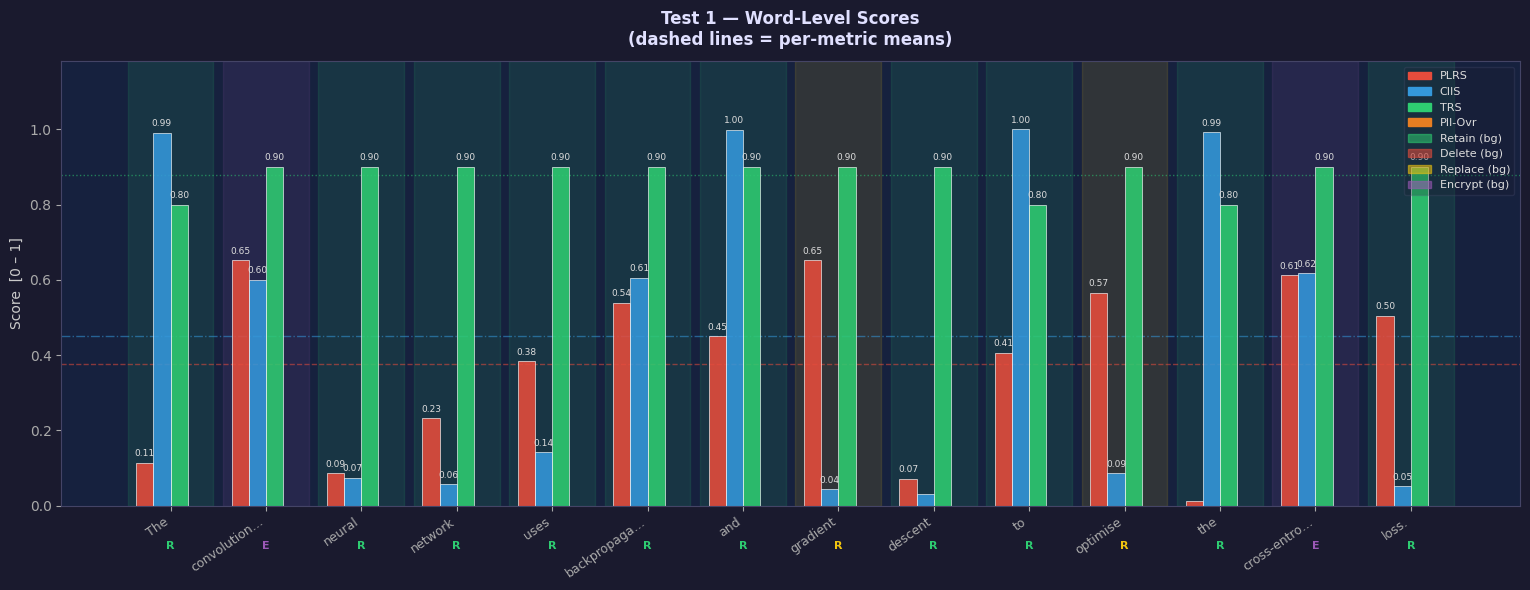


  Legend: ■ Retain  ■ Delete  ■ Replace  ■ Encrypt

  Masked Prompt:
  » The [MASK] neural network uses backpropagation and gradient descent to optimise the [MASK] loss.

  Encrypt Self-Recommendation Candidates:
    ✓ 1. The David Miller neural network uses backpropagation and gradient descent to optimise the 0.000123 loss.
      2. The Emily Patel neural network uses backpropagation and gradient descent to optimise the 0.000456 loss.
      3. The Michael Brown neural network uses backpropagation and gradient descent to optimise the 0.000789 loss.

  Sanitised Output:
  » The David Miller neural network uses backpropagation and gradient descent to optimise the 0.000123 loss.

  ⏱  96.7s

════════════════════════════════════════════════════════════════════════════════════════════════════
║                                       All tests complete.                                        ║
═══════════════════════════════════════════════════════════════════════════════════════════════════

In [34]:
async def run_tests() -> None:
    print('\n')
    _sep()
    _header('Privacy-Preserving NLP Pipeline — Llama-3 TRS + Self-Recommendation (Colab)')
    _sep()
    print()

    log.info('All models ready — running %d test cases …\n', len(TEST_CASES))

    for idx, prompt in enumerate(TEST_CASES, 1):
        _sep('─')
        print(f'\n  {C.BOLD}{C.CYAN}TEST CASE {idx} / {len(TEST_CASES)}{C.RESET}\n')
        print(f'  {C.BOLD}Original Prompt:{C.RESET}')
        print(f'  {C.WHITE}» {prompt}{C.RESET}\n')

        t0 = time.perf_counter()
        try:
            result = await run_pipeline(prompt)
        except Exception as exc:
            print(f'  {C.RED}ERROR: {exc}{C.RESET}\n')
            continue
        elapsed = time.perf_counter() - t0

        print(f'  {C.BOLD}Per-Word Analysis:{C.RESET}  (★ = PII regex hard-override)')
        _print_table(result)
        generate_score_chart(result, idx)

        print()
        print(f'  Legend: {C.GREEN}■ Retain{C.RESET}  {C.RED}■ Delete{C.RESET}'
              f'  {C.YELLOW}■ Replace{C.RESET}  {C.MAGENTA}■ Encrypt{C.RESET}')

        if result.get('masked_prompt'):
            print(f'\n  {C.BOLD}Masked Prompt:{C.RESET}')
            print(f"  {C.YELLOW}» {result['masked_prompt']}{C.RESET}")

        if result.get('encrypt_candidates'):
            print(f'\n  {C.BOLD}Encrypt Self-Recommendation Candidates:{C.RESET}')
            for ci, cand in enumerate(result['encrypt_candidates'], 1):
                marker = f'{C.GREEN}✓{C.RESET}' if cand == result['sanitised'] else ' '
                print(f'    {marker} {C.BLUE}{ci}.{C.RESET} {cand}')

        print(f'\n  {C.BOLD}Sanitised Output:{C.RESET}')
        print(f"  {C.GREEN}» {result['sanitised']}{C.RESET}")

        print(f'\n  {C.GREY}⏱  {elapsed:.1f}s{C.RESET}\n')

    _sep()
    _header('All tests complete.')
    _sep()
    print()


await run_tests()


## 15. (Optional) FastAPI wrapper — for local deployment

The cells below reproduce the original REST wrapper. They're not needed to use the pipeline
in Colab, but they're included so the notebook is a complete port with no lost logic. To run
as a server you would typically export the notebook to a `.py` file and launch with
`uvicorn app:app --reload` locally.


In [ ]:
class PromptRequest(BaseModel):
    prompt: str


class WordAnalysis(BaseModel):
    word:         str
    plrs:         float
    ciis:         float
    trs:          float
    pii_override: float
    cluster_id:   int
    action:       str


class PipelineResponse(BaseModel):
    original_prompt:    str
    word_analyses:      List[WordAnalysis]
    sanitised_prompt:   str
    masked_prompt:      Optional[str] = None
    encrypt_candidates: Optional[List[str]] = None


@asynccontextmanager
async def lifespan(app: FastAPI):
    # Registry is already populated by cell 6.3 in the Colab session.
    log.info('=== FastAPI app started (registry pre-loaded). ===')
    yield
    log.info('=== FastAPI app shutting down. ===')


app = FastAPI(
    title='Privacy-Preserving NLP Pipeline',
    description='Word-level anonymisation via PLRS · CIIS · TRS',
    version='2.0.0',
    lifespan=lifespan,
)


@app.get('/health', tags=['Meta'])
async def health_check():
    return {
        'status': 'ok',
        'device': str(registry.device),
        'models': [BERT_MODEL_NAME, GPT2_MODEL_NAME, SPACY_MODEL_NAME, LLAMA_MODEL_NAME],
    }


@app.post('/analyse', response_model=PipelineResponse, tags=['Pipeline'])
async def analyse_prompt(body: PromptRequest):
    try:
        result = await run_pipeline(body.prompt)
    except ValueError as exc:
        raise HTTPException(status_code=422, detail=str(exc))
    except Exception as exc:
        log.exception('Pipeline error')
        raise HTTPException(status_code=500, detail=str(exc))

    word_analyses = [
        WordAnalysis(
            word         = result['words'][i],
            plrs         = round(result['plrs'][i], 4),
            ciis         = round(result['ciis'][i], 4),
            trs          = round(result['trs'][i], 4),
            pii_override = round(result['pii_override'][i], 4),
            cluster_id   = result['cluster_ids'][i],
            action       = result['actions'][i],
        )
        for i in range(len(result['words']))
    ]
    return PipelineResponse(
        original_prompt    = body.prompt,
        word_analyses      = word_analyses,
        sanitised_prompt   = result['sanitised'],
        masked_prompt      = result.get('masked_prompt'),
        encrypt_candidates = result.get('encrypt_candidates'),
    )

print('FastAPI app object prepared at `app` — export this file and run `uvicorn app:app`.')
